Exp 7: Anomaly Detection: Implement an anomaly detection system
for detecting outliers in data (e.g., fraud detection) and perform
comparative analysis. (Isolation Forest, Local Outlier Factor,
One-Class SVM)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score



In [2]:
data = pd.read_csv("/content/drive/MyDrive/AIML_LAB/Exp 5_6_7_8/anomaly_detection_dataset_500_samples.csv")
data.head()

,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


In [3]:
X = data[["Feature_1", "Feature_2"]]
y_true = data["Anomaly_Label"]
data.head()

,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


In [4]:
iso = IsolationForest(contamination=0.1, random_state=42)
y_pred_iso = iso.fit_predict(X)
y_pred_iso = [1 if i == -1 else 0 for i in y_pred_iso]
data.head()

,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


In [5]:
print("Isolation Forest Results:")
print(classification_report(y_true, y_pred_iso))
data.head()

Isolation Forest Results:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98       470
           1       0.60      1.00      0.75        30

    accuracy                           0.96       500
   macro avg       0.80      0.98      0.86       500
weighted avg       0.98      0.96      0.96       500



,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


In [6]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred_lof = lof.fit_predict(X)
y_pred_lof = [1 if i == -1 else 0 for i in y_pred_lof]

print("Local Outlier Factor Results:")
print(classification_report(y_true, y_pred_lof))
data.head()

Local Outlier Factor Results:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       470
           1       0.02      0.03      0.03        30

    accuracy                           0.84       500
   macro avg       0.48      0.46      0.47       500
weighted avg       0.88      0.84      0.86       500



,Feature_1,Feature_2,Anomaly_Label
0,43.259073,53.716320,0
1,43.815246,43.397717,0
2,46.942411,42.966695,0
3,48.911594,55.493884,0
4,52.575238,69.263657,0


In [7]:
ocsvm = OneClassSVM(kernel="rbf", nu=0.1, gamma=0.1)
y_pred_svm = ocsvm.fit_predict(X)
y_pred_svm = [1 if i == -1 else 0 for i in y_pred_svm]

print("One-Class SVM Results:")
print(classification_report(y_true, y_pred_svm))


One-Class SVM Results:
              precision    recall  f1-score   support

           0       0.95      0.76      0.84       470
           1       0.08      0.33      0.13        30

    accuracy                           0.73       500
   macro avg       0.51      0.55      0.49       500
weighted avg       0.90      0.73      0.80       500



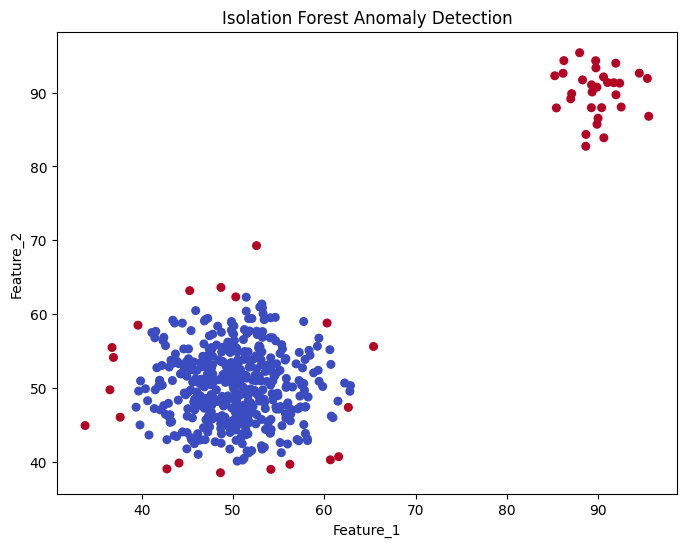

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(X["Feature_1"], X["Feature_2"], c=y_pred_iso, cmap="coolwarm", s=30)
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.show()
